<a target="_blank" href="https://colab.research.google.com/github/TransformerLensOrg/TransformerLens/blob/main/demos/Jacobian_Lens_Demo.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jacobian Lens (J-lens) Demo

The **Jacobian lens** characterizes an intermediate residual-stream activation by its
*first-order causal effect on the model's output*, averaged over a corpus of contexts. For each
layer $\ell$ it uses a single matrix $J_\ell = \mathbb{E}[\partial h_{\mathrm{final},t'} /
\partial h_{\ell,t}]$ mapping the output of block $\ell$ to the final block's output, and reads
tokens with the model's own unembedding: $\mathrm{lens}(h_\ell) = \mathrm{softmax}(W_U\,
\mathrm{norm}(J_\ell h_\ell))$. The logit lens is the special case $J_\ell = I$; the J-lens is
its causal, corpus-averaged correction, and it surfaces interpretable content at depths where the
logit lens reads noise.

Introduced in [*Verbalizable Representations Form a Global Workspace in Language Models*](https://transformer-circuits.pub/2026/workspace/index.html)
(Gurnee et al., Transformer Circuits Thread, 2026). Pre-fitted lenses for 38 open models are
published at [`neuronpedia/jacobian-lens`](https://huggingface.co/neuronpedia/jacobian-lens), and
an interactive version lives at [neuronpedia.org/jlens](https://www.neuronpedia.org/jlens).

This demo, on `gemma-2-2b`:

1. loads a published lens from the Hub,
2. reads J-lens vs logit-lens tokens on a two-hop prompt with an *unspoken intermediate*,
3. causally swaps one concept for another (France → China) in lens coordinates, and
4. steers with a J-lens direction.

**Note**: `google/gemma-2-2b` is a gated Hugging Face model — accept its license and authenticate
(`huggingface-cli login` / `HF_TOKEN`) before running. The demo uses ~6 GB of GPU memory
(executed on an 8 GB card), so a free Colab T4 should work.

## Setup (Ignore)

In [1]:
# NBVAL_IGNORE_OUTPUT
# Janky code to do different setup when run in a Colab notebook vs VSCode
import os

DEVELOPMENT_MODE = False
IN_GITHUB = os.getenv("GITHUB_ACTIONS") == "true"
try:
    import google.colab

    IN_COLAB = True
    print("Running as a Colab notebook")
except ImportError:
    IN_COLAB = False
    print("Running as a Jupyter notebook - intended for development only!")
    DEVELOPMENT_MODE = True
    from IPython import get_ipython

    ipython = get_ipython()
    ipython.run_line_magic("load_ext", "autoreload")
    ipython.run_line_magic("autoreload", "2")

if IN_COLAB or IN_GITHUB:
    %pip install transformer_lens

Running as a Jupyter notebook - intended for development only!


In [2]:
# NBVAL_IGNORE_OUTPUT
import torch

from transformer_lens.model_bridge import TransformerBridge
from transformer_lens.tools.analysis import JacobianLens

device = "cuda" if torch.cuda.is_available() else "cpu"
# Raw HF weights (the Bridge default) — the published lenses are fitted on raw
# activations, and JacobianLens refuses fold_ln / compatibility-mode models.
model = TransformerBridge.boot_transformers("google/gemma-2-2b", dtype=torch.bfloat16, device=device)
model.eval()
print(f"loaded gemma-2-2b: {model.cfg.n_layers} layers, d_model={model.cfg.d_model}, {device=}")

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

loaded gemma-2-2b: 26 layers, d_model=2304, device='cuda'


## 1. Load a published lens

One artifact per model: a `[d_model, d_model]` matrix for every layer except the last (the final
layer's transport is the identity by construction). `from_pretrained` validates the lens against
the model and fails loudly on dimension or weight-processing mismatches.

In [3]:
# NBVAL_IGNORE_OUTPUT (download progress)
lens = JacobianLens.from_pretrained(
    "neuronpedia/jacobian-lens",
    filename="gemma-2-2b/jlens/Salesforce-wikitext/gemma-2-2b_jacobian_lens.pt",
    model=model,
)
lens

JacobianLens(layers=0..24 (25), d_model=2304, n_prompts=454)

## 2. Reading: a two-hop prompt with an unspoken intermediate

*"The currency used in the country shaped like a boot"* requires an intermediate step — **Italy** —
that never appears in the prompt. The J-lens surfaces the intermediate and the answer's concept
band in the middle of the model, while the logit lens at the same layers mostly tracks surface
continuations.

In [4]:
PROMPT = "Fact: The currency used in the country shaped like a boot is"

result_jlens = lens.readout(model, PROMPT, positions=[-1])
result_logitlens = lens.readout(model, PROMPT, positions=[-1], use_jacobian=False)

top_j = result_jlens.top_tokens(model.tokenizer, k=5)
top_l = result_logitlens.top_tokens(model.tokenizer, k=5)
print(f"{'layer':>5} | {'J-lens top-5':<55} | logit lens top-5")
for layer in [4, 8, 13, 17, 21, 24, 25]:
    print(f"{layer:>5} | {str(top_j[layer][-1]):<55} | {top_l[layer][-1]}")
print("model output:", top_j[25][-1][0])

layer | J-lens top-5                                            | logit lens top-5
    4 | [' anything', '</strong>', ' ï', ' also', ' –']         | [' is', '<bos>', ' not', ' are', ' was']
    8 | ['\n\n\n', ' $', ' probably', ',$', '\n\n']             | [' is', ' called', ' was', ' are', ' has']
   13 | ['LookAnd', 'RenderAtEndOf', ' famously', 'qrstuvwxyz', 'ⓧ'] | [' is', ' called', ' actually', ' was', ' has']
   17 | ['LookAnd', 'Билгалдахарш', 'RenderAtEndOf', 'BeginContext', 'ftagPool'] | [' called', ' not', ' a', ' the', ' ']
   21 | [' euro', ' currency', ' euros', ' Euros', ' Euro']     | [' called', ' the', ' not', ' a', ' ']
   24 | [' the', ' called', ' euro', ' euros', ' Euro']         | [' the', ' called', ' not', ' known', ' a']
   25 | [' the', ' called', ' not', ' known', ' a']             | [' the', ' called', ' not', ' known', ' a']
model output:  the


The answer concept (` euro`) and the intermediate's semantic neighborhood dominate the J-lens
readout from the middle of the model onward; the logit lens catches up only in the last few
layers, where $J_\ell \to I$ and the two lenses converge. (Early layers are noise under both —
the paper's "sensory" band. The recurring code-ish tokens in early J-lens readouts are a known
signature of gemma-2-2b's lens.)

We can watch each concept's *rank trajectory* across depth:

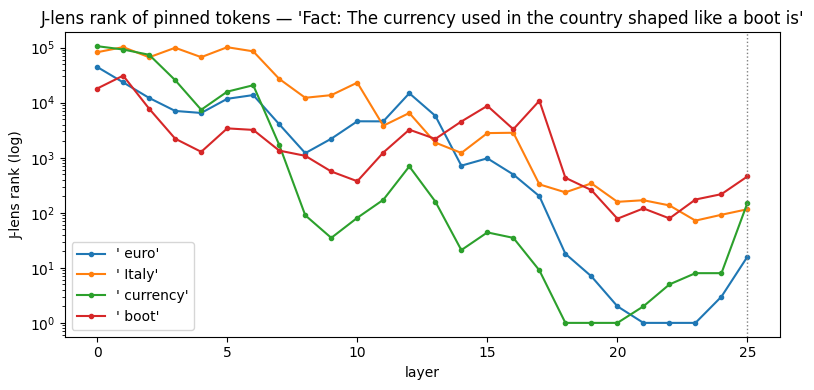

In [5]:
import matplotlib.pyplot as plt

PINNED = [" euro", " Italy", " currency", " boot"]
ranks = {token: [] for token in PINNED}
layers = list(range(model.cfg.n_layers))
for token in PINNED:
    token_id = model.to_single_token(token)
    for layer in layers:
        logits = result_jlens.lens_logits[layer][-1]
        ranks[token].append(int((logits > logits[token_id]).sum().item()) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
for token, values in ranks.items():
    ax.plot(layers, values, marker="o", markersize=3, label=repr(token))
ax.set(yscale="log", xlabel="layer", ylabel="J-lens rank (log)", title=f"J-lens rank of pinned tokens — {PROMPT!r}")
ax.axvline(25, color="gray", ls=":", lw=1)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Intervening: swap France for China in lens coordinates

The paper's *flexible generalization* protocol: pick source and target tokens, form
$V = [v_s, v_t]$ from their J-lens vectors, read the activation's lens coordinates $c = V^+ h$
(pseudoinverse), and write back $h \leftarrow h + \alpha\, V(\sigma(c) - c)$ where $\sigma$
exchanges the two coordinates — leaving the orthogonal complement of the activation untouched.
The swap is clamped at every token position across an intermediate-layer band (layers 10–24 ≈
the paper's 38–92% workspace band).

In [6]:
def show_next_tokens(prompt, hooks=None, k=5):
    tokens = model.to_tokens(prompt)
    with torch.no_grad():
        if hooks:
            with model.hooks(fwd_hooks=hooks):
                logits = model(tokens)[0, -1].float()
        else:
            logits = model(tokens)[0, -1].float()
    top = logits.topk(k).indices.tolist()
    return [model.tokenizer.decode([t]) for t in top]

BAND = range(10, 25)
swap = lens.swap_hooks(model, " France", " China", layers=BAND, alpha=1.0)

for prompt in ["Most people in France speak", "The capital of France is"]:
    print(f"{prompt!r}")
    print("  baseline :", show_next_tokens(prompt))
    print("  swapped  :", show_next_tokens(prompt, hooks=swap))

'Most people in France speak'
  baseline : [' French', ' English', ' a', ' at', ' the']
  swapped  : [' Chinese', ' English', ' a', ' some', ' the']
'The capital of France is'


  baseline : [' a', ' the', ' one', ' also', ' home']
  swapped  : [' a', ' the', ' one', ' also', ' home']


In [7]:
# Rank of the China-appropriate answer, before and after the swap
for prompt, answer in [("Most people in France speak", " Chinese"), ("The capital of France is", " Beijing")]:
    answer_id = model.to_single_token(answer)
    tokens = model.to_tokens(prompt)
    with torch.no_grad():
        base = model(tokens)[0, -1].float()
        with model.hooks(fwd_hooks=swap):
            swapped = model(tokens)[0, -1].float()
    base_rank = int((base > base[answer_id]).sum().item())
    swap_rank = int((swapped > swapped[answer_id]).sum().item())
    print(f"{prompt!r}: rank of {answer!r} {base_rank} -> {swap_rank}")

'Most people in France speak': rank of ' Chinese' 347 -> 0
'The capital of France is': rank of ' Beijing' 968 -> 8


At $\alpha=1$ the language template flips top-1 outright (`French` → `Chinese`), and the
China-appropriate answers jump hundreds of ranks on the others — the same swap redirecting
*different* downstream computations, which is the broadcast/workspace claim. (On this small base
model the capital template's top-1 is a filler word even unperturbed; the paper reports 42/48
top-1 success for country swaps on Claude Sonnet 4.5, and that doubling to $\alpha=2$ recovers
some $\alpha=1$ failures. On gemma-2-2b we instead observe $\alpha=2$ overshooting into
verbalizing the injected concept — the swapped prompt's top-1 becomes ` China` itself — so
$\alpha=1$ is the better default here.)

## 4. Steering along a J-lens vector

`steering_hooks` adds a token's unit-normalized lens direction, scaled by the activation's mean
residual norm times `alpha` (the paper's directed-modulation protocol). `ablation_hooks`
(projecting a direction *out*) works the same way.

In [8]:
steer = lens.steering_hooks(model, " Paris", layers=range(10, 21), alpha=2.0)
prompt = "This weekend I am planning a trip to"
print("baseline :", show_next_tokens(prompt))
print("steered  :", show_next_tokens(prompt, hooks=steer))

baseline : [' the', ' a', ' my', ' visit', ' see']
steered  : [' paris', ' Paris', 'Paris', ' París', 'paris']


## 5. Fitting your own lens

For models without a published artifact, `JacobianLens.fit` reproduces the reference estimator on
any hooked model (raw weights) — one forward and `ceil(d_model / dim_batch)` backward passes per
prompt, deterministic. Quality saturates quickly: ~100 prompts of 128 tokens is usable (the
published lenses use up to 1000). Fits parallelize across prompt slices and combine exactly with
`merge`:

```python
from datasets import load_dataset

texts = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="train", streaming=True)
prompts = [row["text"] for row in texts.take(500) if len(row["text"]) > 600][:100]

lens = JacobianLens.fit(model, prompts, dim_batch=16, max_seq_len=128)
lens.save("gemma-2-2b_jlens.pt")           # official artifact format (+ provenance metadata)
# ...or shard: JacobianLens.merge([fit(model, chunk) for chunk in chunks])
```

## References

- Gurnee et al., [*Verbalizable Representations Form a Global Workspace in Language Models*](https://transformer-circuits.pub/2026/workspace/index.html), Transformer Circuits Thread, 2026
- Reference implementation: [`anthropics/jacobian-lens`](https://github.com/anthropics/jacobian-lens) (Apache-2.0)
- Published lenses: [`neuronpedia/jacobian-lens`](https://huggingface.co/neuronpedia/jacobian-lens) · interactive: [neuronpedia.org/jlens](https://www.neuronpedia.org/jlens)
- The logit lens: [nostalgebraist, 2020](https://www.lesswrong.com/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens)